HEART DISEASE PREDICTION

In [1]:
# necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

EDA and Data-cleaning

In [2]:
heart_data: pd.DataFrame = pd.read_csv("heart_dataset.csv")
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
r, c = heart_data.shape
print(f"Rows : {r}\nColumns : {c}")

Rows : 918
Columns : 12


In [4]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [5]:
heart_data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
# missing-values
heart_data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
# duplicate-rows
heart_data.duplicated().sum()

np.int64(0)

In [8]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
quant_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',]
catg_vars = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

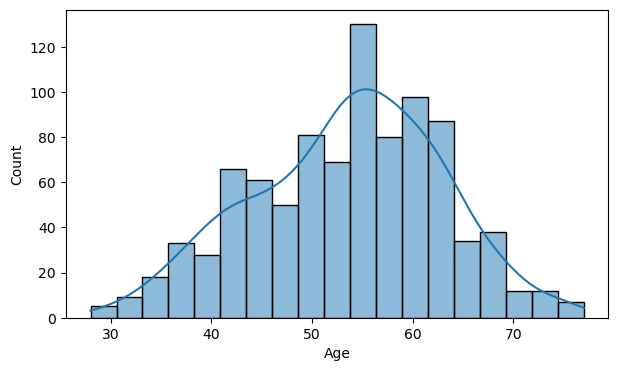

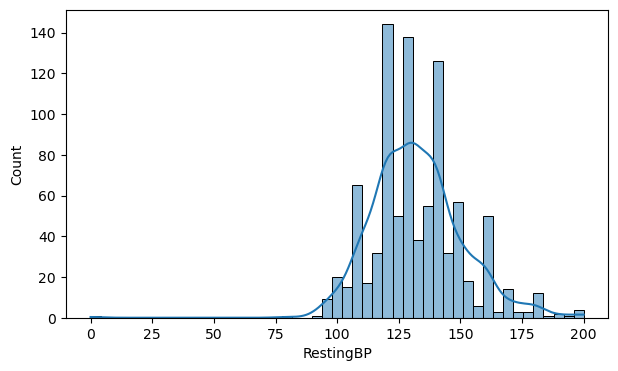

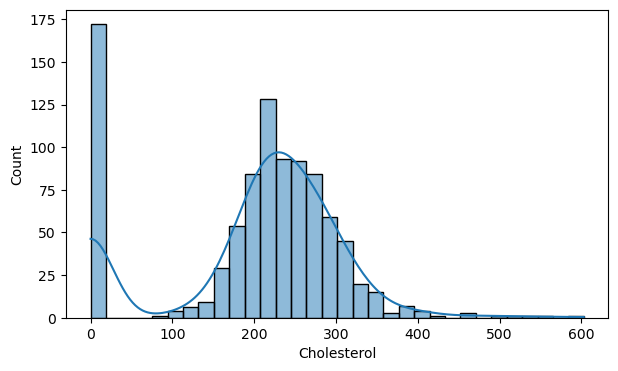

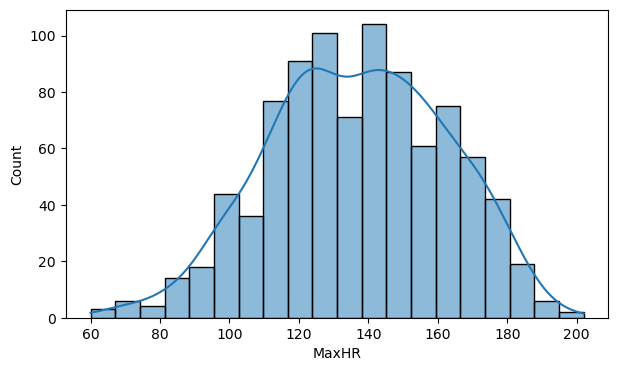

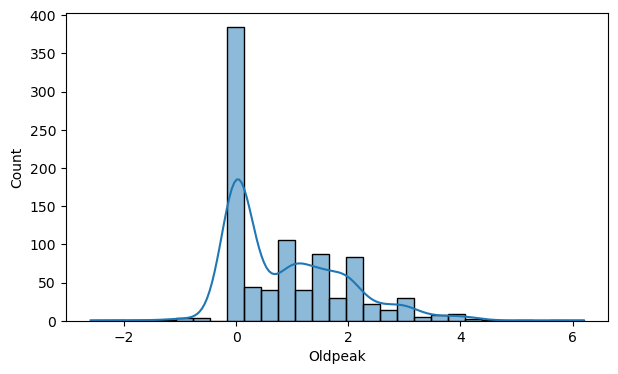

In [10]:
# histogram-plots
for var in quant_vars:
    plt.figure(figsize = (7, 4))
    sns.histplot(x = heart_data[var], kde = True)

In [11]:
# restingbp and cholesterol
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [12]:
heart_data[heart_data['Cholesterol'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [13]:
median_chol = int(heart_data['Cholesterol'].median())
heart_data['Cholesterol'] = heart_data['Cholesterol'].replace(0, median_chol)

<Axes: xlabel='Cholesterol', ylabel='Count'>

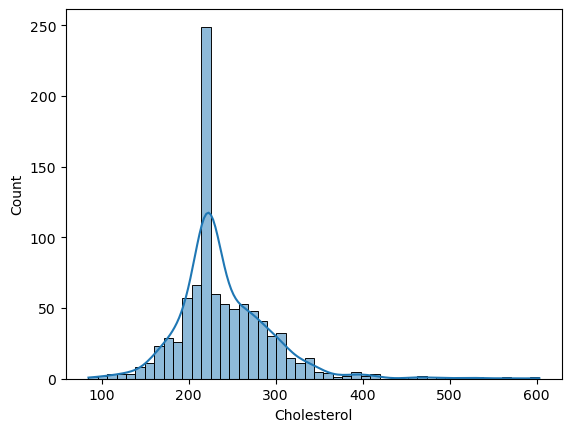

In [14]:
sns.histplot(x = heart_data['Cholesterol'], kde = True)

In [15]:
heart_data[heart_data['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,223,0,Normal,155,N,1.5,Flat,1


In [16]:
heart_data = heart_data[heart_data['RestingBP'] != 0]

<Axes: xlabel='RestingBP', ylabel='Count'>

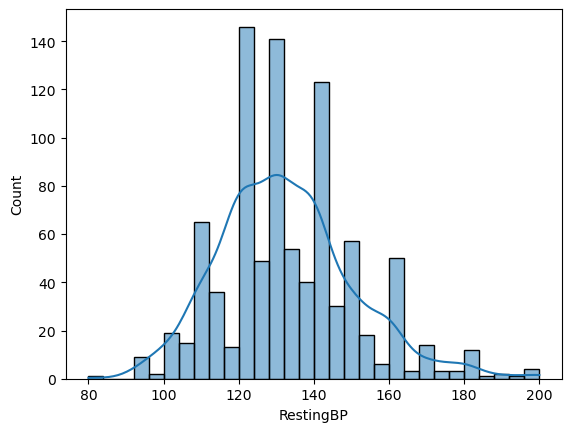

In [17]:
sns.histplot(x = heart_data['RestingBP'], kde = True)

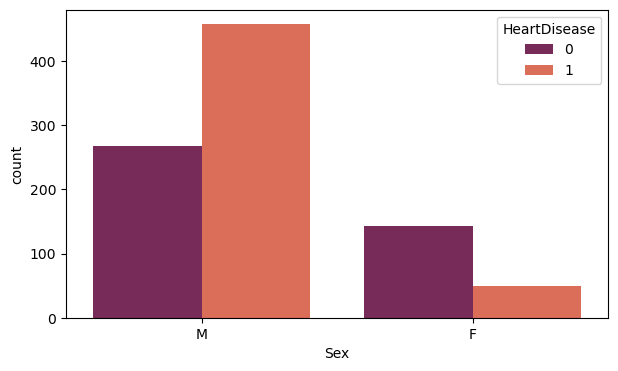

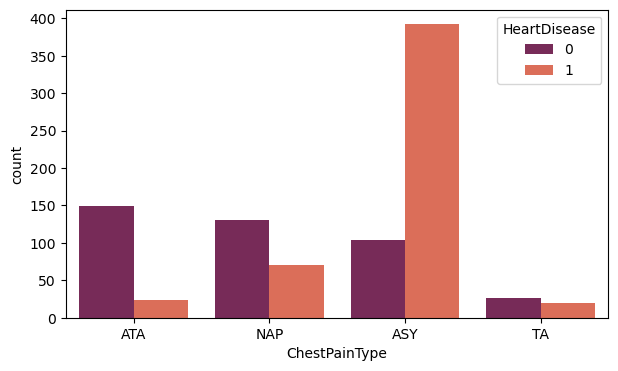

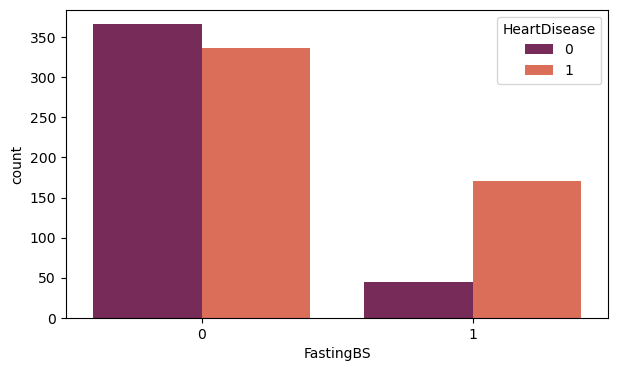

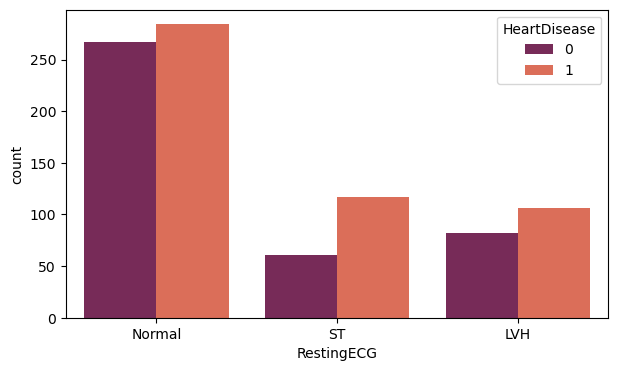

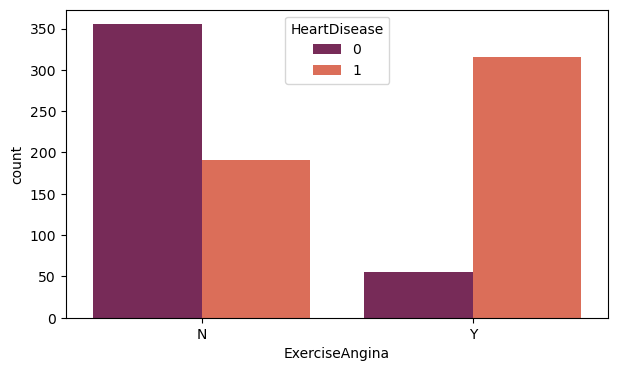

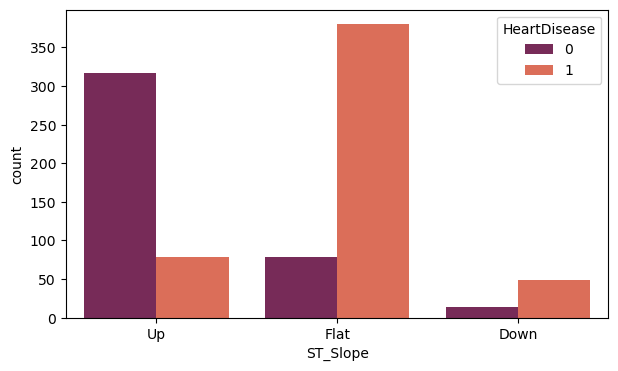

In [18]:
# count-plots
for var in catg_vars:
    plt.figure(figsize = (7, 4))
    sns.countplot(x = heart_data[var], hue = heart_data['HeartDisease'], palette = 'rocket')

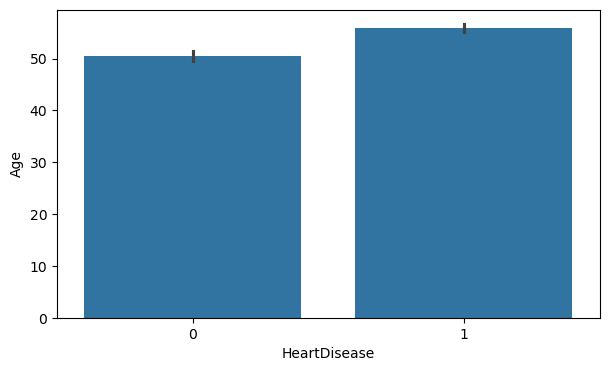

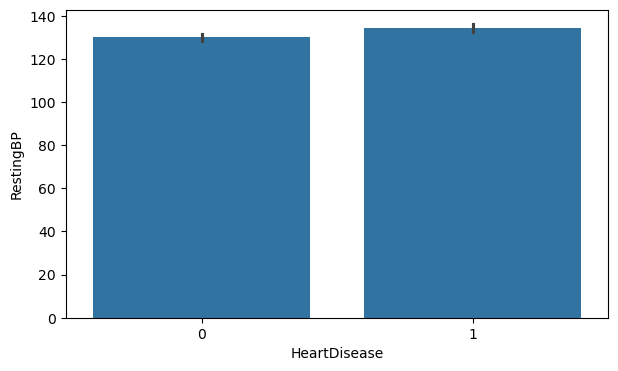

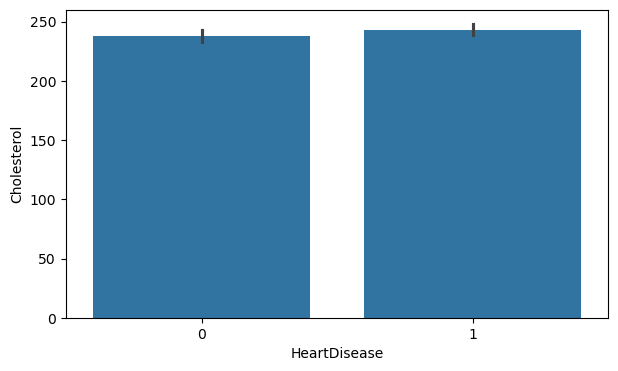

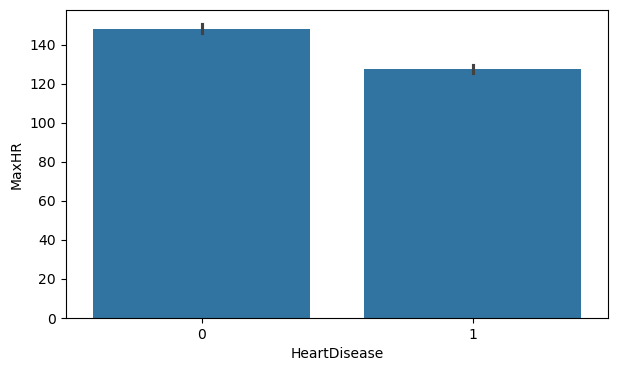

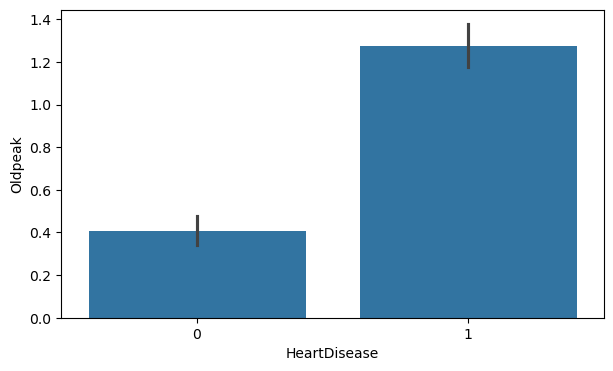

In [19]:
# bar-plots
for var in quant_vars :
    plt.figure(figsize = (7, 4))
    sns.barplot(x = heart_data['HeartDisease'], y = heart_data[var])

<Axes: >

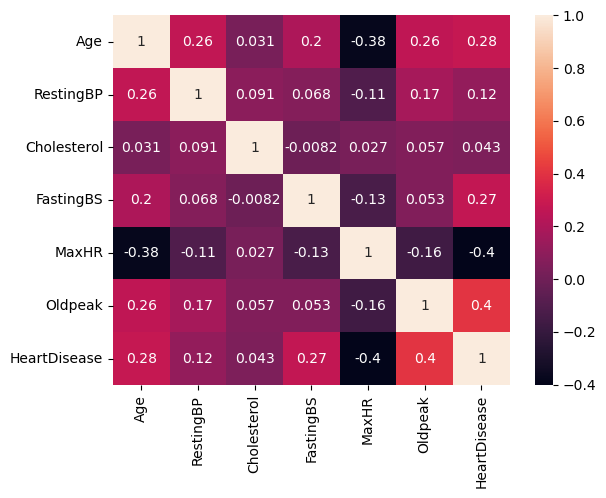

In [20]:
# heat-map
sns.heatmap(heart_data.corr(numeric_only = True), annot = True)

In [21]:
# chi-square test
from scipy.stats import chi2_contingency
# H0 : no significant relationship between input_feature(catg) and target_feature(catg)
# H1 : significant relationship..
sig_level = 0.05
chi2_results = {}
for var in catg_vars :
    contingency_table = pd.crosstab(heart_data[var], heart_data['HeartDisease'])
    chi2_stats, p_val, _, _ = chi2_contingency(contingency_table)
    chi2_results[var] = 'keep feature' if p_val < sig_level else 'discard feature' # type: ignore

print(chi2_results)

{'Sex': 'keep feature', 'ChestPainType': 'keep feature', 'FastingBS': 'keep feature', 'RestingECG': 'keep feature', 'ExerciseAngina': 'keep feature', 'ST_Slope': 'keep feature'}


In [22]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Data Pre-processing

In [23]:
# label-encoding
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].str.strip().str.upper()
heart_data['ExerciseAngina'] = heart_data['ExerciseAngina'].map({'N' : 0, 'Y' : 1})

In [24]:
heart_data['Sex'] = heart_data['Sex'].str.strip().str.upper()
heart_data['Sex'] = heart_data['Sex'].map({'M' : 1, 'F' : 0})

In [25]:
heart_data.rename(columns = {'Sex' : 'Is_male', 'ChestPainType' : 'CP_type', 'FastingBS' : 'f_BS', 'RestingECG' : 'r_ECG'}, inplace = True)

In [26]:
heart_data.head()

,Age,Is_male,CP_type,RestingBP,Cholesterol,f_BS,r_ECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [27]:
# one-hot encoding
heart_data_enc = pd.get_dummies(heart_data, columns = ['CP_type', 'r_ECG', 'ST_Slope'])

In [28]:
heart_data_enc.head()

,Age,Is_male,RestingBP,Cholesterol,f_BS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,CP_type_ASY,CP_type_ATA,CP_type_NAP,CP_type_TA,r_ECG_LVH,r_ECG_Normal,r_ECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,False,True,False,False,False,True,False,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,1,130,283,0,98,0,0.0,0,False,True,False,False,False,False,True,False,False,True
3,48,0,138,214,0,108,1,1.5,1,True,False,False,False,False,True,False,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,False,True,False,False,True,False,False,False,True


In [29]:
for col in heart_data_enc.columns :
    if heart_data_enc[col].dtype == bool :
        heart_data_enc[col] = heart_data_enc[col].astype(int)
    else :
        continue

In [30]:
heart_data_enc.head()

,Age,Is_male,RestingBP,Cholesterol,f_BS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,CP_type_ASY,CP_type_ATA,CP_type_NAP,CP_type_TA,r_ECG_LVH,r_ECG_Normal,r_ECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


In [31]:
heart_data_ns = heart_data_enc.copy()

In [32]:
# feature-scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

heart_data_enc[cols] = scaler.fit_transform(heart_data_enc[cols])

In [33]:
heart_data_enc.head()

,Age,Is_male,RestingBP,Cholesterol,f_BS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,CP_type_ASY,CP_type_ATA,CP_type_NAP,CP_type_TA,r_ECG_LVH,r_ECG_Normal,r_ECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.432206,1,0.414627,0.896615,0,1.383339,0,-0.831502,0,0,1,0,0,0,1,0,0,0,1
1,-0.478057,0,1.526360,-1.122657,0,0.754736,0,0.106251,1,0,0,1,0,0,1,0,0,1,0
2,-1.750256,1,-0.141240,0.785462,0,-1.523953,0,-0.831502,0,0,1,0,0,0,0,1,0,0,1
3,-0.584074,0,0.303453,-0.492793,0,-1.131075,1,0.575128,1,1,0,0,0,0,1,0,0,1,0
4,0.052026,1,0.970493,-0.844776,0,-0.581047,0,-0.831502,0,0,0,1,0,0,1,0,0,0,1


Model creation and evaluation

In [34]:
# train-test-split
from sklearn.model_selection import train_test_split

X: pd.DataFrame = heart_data_enc.drop('HeartDisease', axis = 1)
y: pd.Series = heart_data_enc['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [35]:
# models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'logistic-regression' : LogisticRegression(),
    'knn' : KNeighborsClassifier(n_neighbors = 5),
    'naive-bayes' : GaussianNB(),
    'decision-trees' : DecisionTreeClassifier(),
    'svm' : SVC(kernel = 'rbf')
}

model_report = {}
for model_name, model_ins in models.items() :
    model_ins.fit(X_train, y_train)
    y_pred = model_ins.predict(X_test)
    model_report[model_name] = {
        'accuracy' : round(accuracy_score(y_test, y_pred), 3),
        'precision' : round(precision_score(y_test, y_pred), 3), # type: ignore
        'recall' : round(recall_score(y_test, y_pred), 3), # type: ignore
        'f1-score' : round(f1_score(y_test, y_pred), 3) # type: ignore
    }

model_report

{'logistic-regression': {'accuracy': 0.87,
  'precision': 0.923,
  'recall': 0.857,
  'f1-score': 0.889},
 'knn': {'accuracy': 0.886,
  'precision': 0.917,
  'recall': 0.893,
  'f1-score': 0.905},
 'naive-bayes': {'accuracy': 0.815,
  'precision': 0.906,
  'recall': 0.777,
  'f1-score': 0.837},
 'decision-trees': {'accuracy': 0.772,
  'precision': 0.865,
  'recall': 0.741,
  'f1-score': 0.798},
 'svm': {'accuracy': 0.875,
  'precision': 0.916,
  'recall': 0.875,
  'f1-score': 0.895}}

In [37]:
# final-model
model_KNN = KNeighborsClassifier()
model_KNN.fit(X_train, y_train)

y_pred = model_KNN.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred, labels = [1, 0]))
print(classification_report(y_test, y_pred))

[[100  12]
 [  9  63]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        72
           1       0.92      0.89      0.90       112

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [38]:
# pickle-files
import joblib
joblib.dump(model_KNN, "model_KNN.pkl")
joblib.dump(scaler, "std_scaler.pkl")
joblib.dump(X.columns.to_list(), "exp_cols.pkl")

['exp_cols.pkl']

In [54]:
# hyperparameter tuning for knn
from sklearn.model_selection import GridSearchCV

hyperparams_comb = {
    'n_neighbors' : [3, 5, 7, 9],
    'weights' : ['uniform', 'distance'],
    'metric' : ['manhattan', 'euclidean']
}

tuning_acc = GridSearchCV((model_KNN), hyperparams_comb, cv = 5, return_train_score = False)
tuning_acc.fit(X, y)

tuning_f1 = GridSearchCV((model_KNN), hyperparams_comb, cv = 5, return_train_score = False, scoring = 'f1')
tuning_f1.fit(X, y)

tuning_res_acc: pd.DataFrame = pd.DataFrame(tuning_acc.cv_results_)
tuning_res_acc = tuning_res_acc[['param_metric', 'param_n_neighbors', 'param_weights', 'mean_test_score']]

tuning_res_f1: pd.DataFrame = pd.DataFrame(tuning_f1.cv_results_)
tuning_res_f1 = tuning_res_f1[['param_metric', 'param_n_neighbors', 'param_weights', 'mean_test_score']]

In [55]:
tuning_res_acc[tuning_res_acc['mean_test_score'] == tuning_res_acc['mean_test_score'].max()]

,param_metric,param_n_neighbors,param_weights,mean_test_score
7,manhattan,9,distance,0.841821


In [56]:
tuning_res_f1[tuning_res_f1['mean_test_score'] == tuning_res_f1['mean_test_score'].max()]

,param_metric,param_n_neighbors,param_weights,mean_test_score
7,manhattan,9,distance,0.85658


In [57]:
# bagging : random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf, labels = [1, 0]))
print(classification_report(y_test, y_pred_rf))

[[99 13]
 [ 9 63]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        72
           1       0.92      0.88      0.90       112

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [58]:
# boosting : xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators = 100, learning_rate = 0.1, random_state = 42, max_depth = 3)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb, labels = [1, 0]))
print(classification_report(y_test, y_pred_xgb))

[[99 13]
 [13 59]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        72
           1       0.88      0.88      0.88       112

    accuracy                           0.86       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



In [59]:
joblib.dump(rf_model, "model_rf.pkl")

['model_rf.pkl']